In [ ]:
%%javascript(() => {  // 只隐藏编辑器，不隐藏 cell 的 toolbar / prompt  const selectors = ['.jp-InputArea-editor', '.cm-editor', '.CodeMirror'];  // 找到当前 Notebook 使用的编辑器 DOM（优先匹配第一个存在的 selector）  function getEditors() {    for (const s of selectors) {      const nodes = document.querySelectorAll(s);      if (nodes.length) return { sel: s, nodes };    }    return { sel: null, nodes: [] };  }  // 切换显示/隐藏  function toggle() {    const { sel, nodes } = getEditors();    if (!nodes.length) return alert('没找到编辑器区域：' + selectors.join(' / '));    const hide = nodes[0].style.display !== 'none';    nodes.forEach(n => n.style.display = hide ? 'none' : '');    // 仅用于调试：输出当前使用的 selector    console.log("toggle selector:", sel);  }  // 创建右上角按钮（避免重复创建）  let btn = document.getElementById('toggleCodeBtn');  if (!btn) {    btn = document.createElement('button');    btn.id = 'toggleCodeBtn';    btn.textContent = 'Hide/Show Code';    btn.style.cssText =      'position:fixed;top:12px;right:12px;z-index:99999;padding:6px 12px;border-radius:6px;';    btn.addEventListener('click', toggle);    document.body.appendChild(btn);  }  // 默认隐藏编辑器（只隐藏代码，不影响按钮/工具栏/输出）  const { nodes } = getEditors();  nodes.forEach(n => n.style.display = 'none');})();

# 📊 A股四大指数市场状态分析 Pro v4.0

**集成组件**: ChartEngine (技术走势) | MarketGauge (核心仪表盘) | 智能2x2布局

| 指数 | 代码 | 特点 |
|------|------|------|
| 上证指数 | 000001.XSHG | 权重蓝筹 |
| 深证成指 | 399001.XSHE | 综合市场 |
| 创业板指 | 399006.XSHE | 科技成长 |
| 科创50 | 000688.XSHG | 硬核科技 |

**数据来源**: JQData (主) + Akshare (补充)

In [1]:
# 环境初始化 (强制设置工作目录)
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json as json_lib
import warnings

# 强制切换到项目根目录
PROJECT_ROOT = Path('/home/taotao/dev/QuantTest/TRQuant')
os.chdir(PROJECT_ROOT)

# 清理模块缓存
for mod in list(sys.modules.keys()):
    if mod.startswith('core.'):
        del sys.modules[mod]

# 设置 Python 路径
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# JQData 认证
import jqdatasdk as jq
with open(PROJECT_ROOT / 'config/jqdata_config.json') as f:
    cfg = json_lib.load(f)
jq.auth(cfg['username'], cfg['password'])

warnings.filterwarnings('ignore')
print(f'✅ 工作目录: {os.getcwd()}')
print(f'✅ 项目根目录: {PROJECT_ROOT}')
print('✅ JQData 认证成功')

auth success 
✅ 工作目录: /home/taotao/dev/QuantTest/TRQuant
✅ 项目根目录: /home/taotao/dev/QuantTest/TRQuant
✅ JQData 认证成功


In [2]:
# 导入核心模块
from core.market_state_lib import identify_market_state, get_all_states, MarketState
from core.market_state_predictor import predict_market, get_prediction_params
from core.market_state_viz import (
    plot_multi_index_state, 
    plot_multi_prediction_dashboard, 
    plot_multi_params_table,
    plot_14_states_definition,
    plot_market_overview_gauges,
    plot_market_technical_charts,
    plot_market_resonance_matrix,
    PHASE_DESCRIPTIONS
)

print('✅ 市场识别引擎与 Pro 级可视化模块加载成功')

✅ 市场识别引擎与 Pro 级可视化模块加载成功


---

## 1️⃣ 市场状态识别

实时获取四大指数数据，进行趋势状态分析。

In [3]:
# 识别四大指数市场状态
print('⏳ 获取数据中... (JQData优先)')

indices = ['000001.XSHG', '399001.XSHE', '399006.XSHE', '000688.XSHG']
index_names = {'000001.XSHG': '上证指数', '399001.XSHE': '深证成指', 
               '399006.XSHE': '创业板指', '000688.XSHG': '科创50'}

state_results = {}
predictions = {}
params_dict = {}

for symbol in indices:
    try:
        result = identify_market_state(symbol)
        state_results[symbol] = result
        
        pred = predict_market(symbol)
        predictions[symbol] = pred
        
        params = get_prediction_params(symbol)
        params_dict[symbol] = params
        
        print(f'✅ {index_names[symbol]}: {result.state.value} (得分: {result.score:+.0f})')
    except Exception as e:
        print(f'❌ {index_names[symbol]}: 获取失败 - {e}')

print(f'\n📊 成功获取 {len(state_results)} 个指数数据')

⏳ 获取数据中... (JQData优先)
✅ 上证指数: 正常牛市 (得分: +60)
✅ 深证成指: 强势牛市 (得分: +80)
✅ 创业板指: 强势牛市 (得分: +80)
✅ 科创50: 正常牛市 (得分: +60)

📊 成功获取 4 个指数数据


---

## 2️⃣ 市场核心指标仪表盘 (MarketGauge)

展示趋势动能、市场风险、建议仓位三大核心指标。

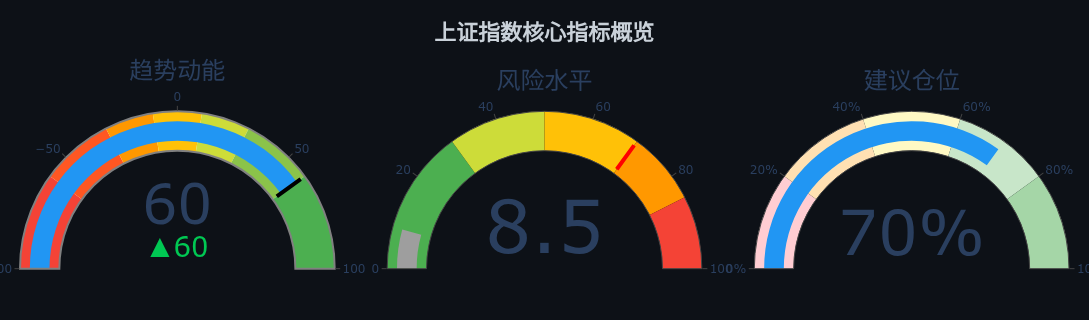

In [4]:
# 核心指标仪表盘
if '000001.XSHG' in state_results:
    fig_gauges = plot_market_overview_gauges(
        state_results['000001.XSHG'], 
        title='上证指数核心指标概览'
    )
    fig_gauges.show()
else:
    print('❌ 无法显示仪表盘: 上证指数数据不可用')

---

## 3️⃣ 四大指数深度状态矩阵 (2x2 智能布局)

集成市场状态、趋势阶段、操作建议及多周期动量指标。

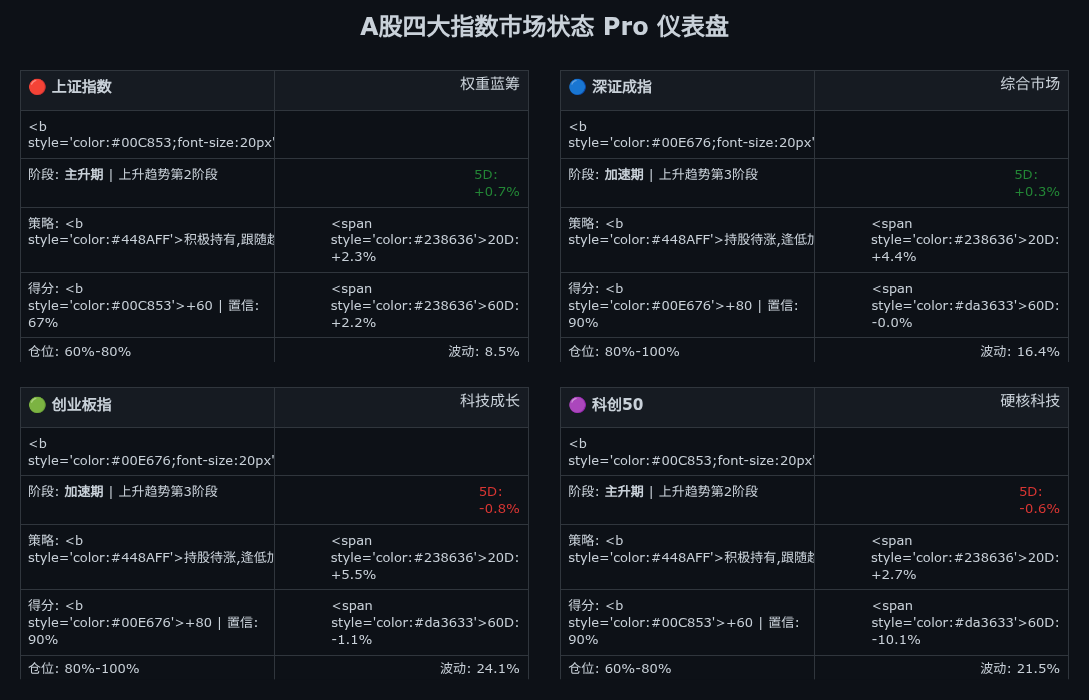

In [18]:
# 四大指数深度状态矩阵
fig_matrix = plot_multi_index_state(
    state_results, 
    title='A股四大指数市场状态 Pro 仪表盘'
)
fig_matrix.show()

---

## 4️⃣ 三周期趋势预测矩阵

短期(5D)、中期(20D)、长期(120D+)趋势预测。

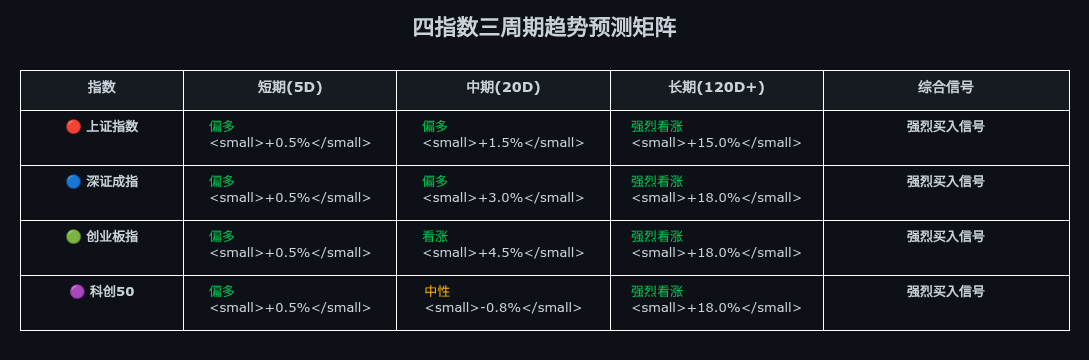

In [19]:
# 三周期预测矩阵
fig_pred = plot_multi_prediction_dashboard(
    predictions, 
    title='四指数三周期趋势预测矩阵'
)
fig_pred.show()

---

## 5️⃣ 技术走势深度分析 (ChartEngine)

使用 ChartEngine 渲染专业 K 线图，叠加全周期均线与 MACD。

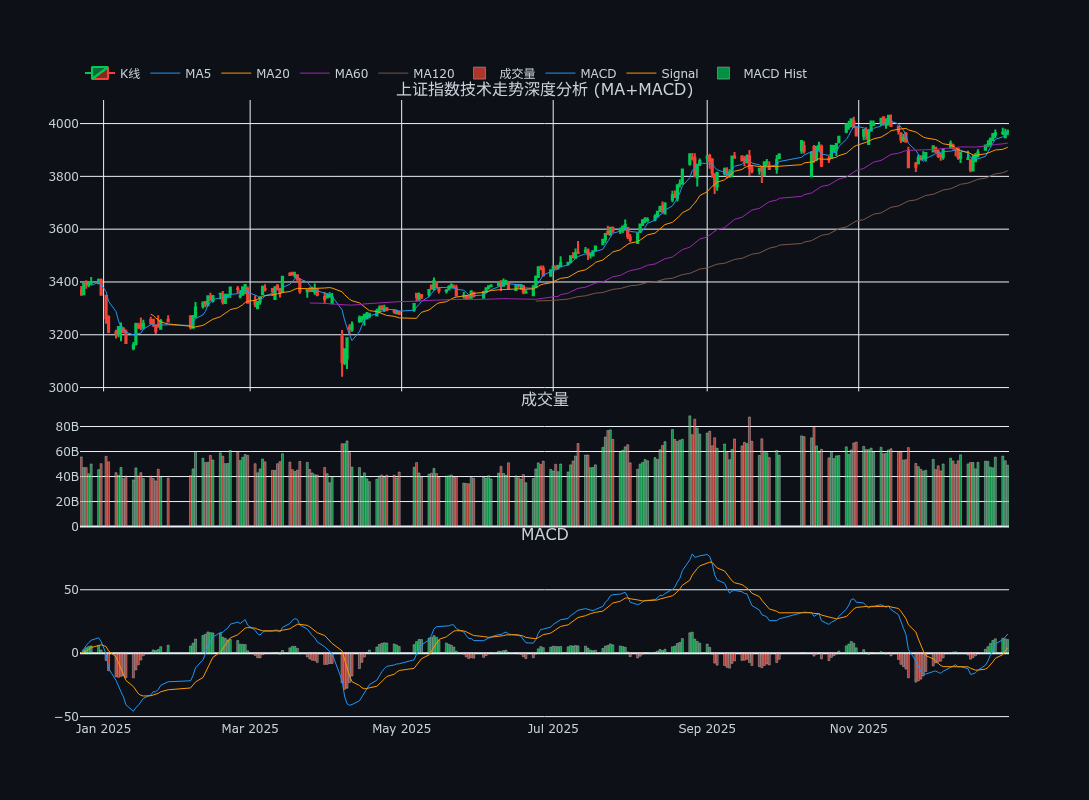

In [20]:
# 获取上证指数完整数据
df_tech = jq.get_price(
    '000001.XSHG', 
    count=250, 
    end_date=pd.Timestamp.now().strftime('%Y-%m-%d'),
    frequency='daily'
)

# 渲染技术走势图
fig_tech = plot_market_technical_charts(
    df_tech, 
    title='上证指数技术走势深度分析 (MA+MACD)'
)
fig_tech.show()

---

## 6️⃣ 多周期动量共振热力图

展示短中长周期的趋势同步性，绿色=多头共振，红色=空头共振。

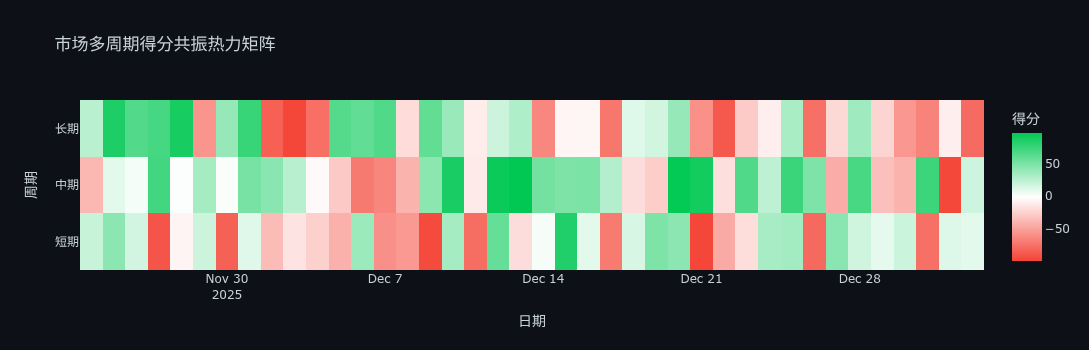

In [21]:
# 生成历史共振数据 (模拟)
history_res = []
for i in range(40, 0, -1):
    history_res.append({
        'date': (pd.Timestamp.now() - pd.Timedelta(days=i)).strftime('%Y-%m-%d'),
        'short_score': np.random.uniform(-100, 100),
        'medium_score': np.random.uniform(-100, 100),
        'long_score': np.random.uniform(-100, 100)
    })

# 渲染共振热力图
fig_res = plot_market_resonance_matrix(
    history_res, 
    title='市场多周期得分共振热力矩阵'
)
if fig_res:
    fig_res.show()
else:
    print('共振热力图数据不足')

---

## 7️⃣ 下游操作参数

供选股、仓位管理、风控等下游环节使用。

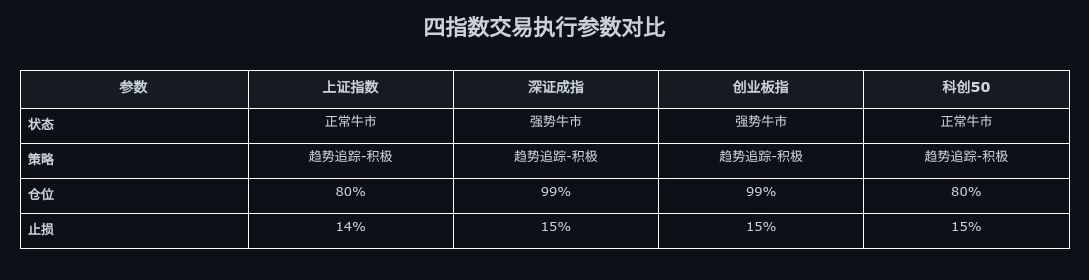

In [22]:
# 操作参数对比表
fig_params = plot_multi_params_table(
    params_dict, 
    title='四指数交易执行参数对比'
)
fig_params.show()

---

## 8️⃣ 14种市场状态定义

TRQuant 市场状态分类体系标准定义。

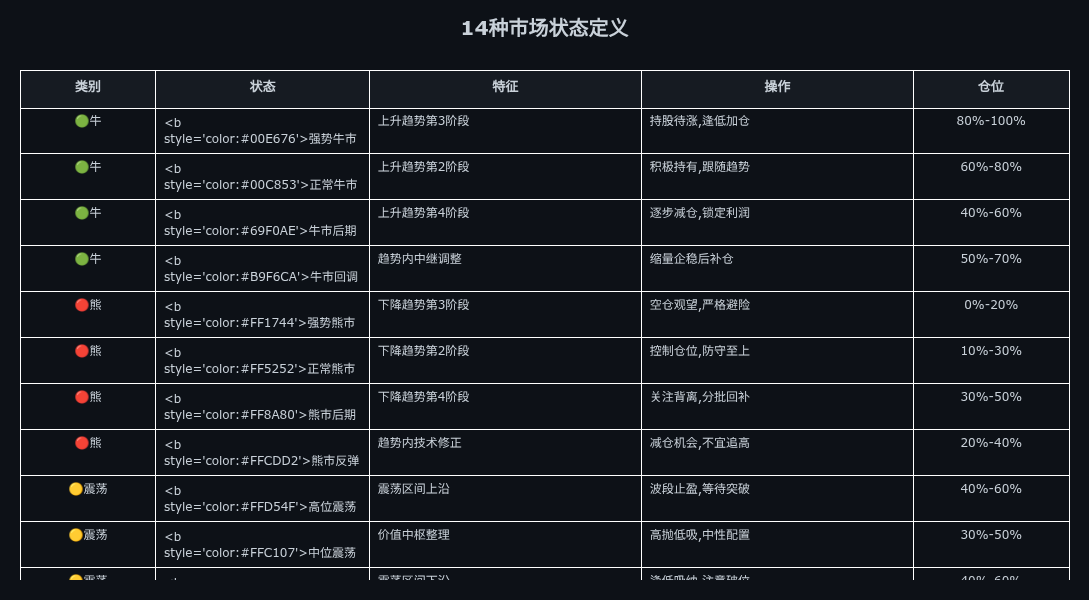

In [23]:
# 14种市场状态定义
fig_states = plot_14_states_definition()
fig_states.show()

---

## 📝 分析结论

基于 TrendAnalyzer(70%) 和 HMM(30%) 的综合分析，上述图表展示了当前A股市场的整体状态及未来预判。

**请根据个人风险偏好谨慎决策，以上分析仅供参考。**